# Hexagonal Nursing Station Analysis
**Article:** *Applying Honeycomb Geometry to Nursing Station Design in Mexican Hospitals*  
**Authors:** Juan Ramón Lara Mora · Diana Paola Ayala Roldán · Luis Mallo Álvarez  

This notebook reproduces all quantitative analyses and figures cited in the article.  
Cells marked `MOCKUP = True` use simulated data; set the flag to `False` and supply real arrays to replace.

---
### Sections
1. [Geometric foundations](#s1)
2. [Unadjusted perimeter comparison](#s2)
3. [Sensitivity analysis across module areas](#s3)
4. [Adjusted perimeter (wall-sharing + passages)](#s4)
5. [Cost analysis](#s5)
6. [Circulation crossing points – schematic](#s6)
7. [Proposed floor plan diagrams](#s7)
8. [Expert perception survey (mockup)](#s8)
9. [Summary table for manuscript](#s9)

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import RegularPolygon, FancyArrowPatch
import pandas as pd
from pathlib import Path

# ── Output directories ──────────────────────────────────────────────────────
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
# Also copy to latex figures folder for direct compilation
LATEX_FIG = Path('../latex_article/figures')
LATEX_FIG.mkdir(parents=True, exist_ok=True)

def save_fig(name, fig=None, dpi=300):
    if fig is None:
        fig = plt.gcf()
    for d in [FIG_DIR, LATEX_FIG]:
        fig.savefig(d / f'{name}.pdf', bbox_inches='tight', dpi=dpi)
        fig.savefig(d / f'{name}.png', bbox_inches='tight', dpi=dpi)
    print(f'Saved → {name}.pdf / .png')

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
})

SQ_COLOR  = '#F5C542'   # yellow  – square
HEX_COLOR = '#E8741A'   # orange  – hexagon

print('Setup complete.')

Setup complete.


<a id='s1'></a>
## 1. Geometric foundations

In [2]:
# ── Core geometry ────────────────────────────────────────────────────────────
A_module = 11.15       # m²  – reference module area (US FGI min single-patient room)
N_modules = 20         # number of modules in the layout
COST_PER_M = 1850      # MXN per linear metre of partition wall

# Square module
l_sq = np.sqrt(A_module)
P_sq = 4 * l_sq                    # perimeter per module

# Hexagonal module (regular, equal area)
l_hex = np.sqrt(2 * A_module / (3 * np.sqrt(3)))
P_hex = 6 * l_hex                  # perimeter per module

# Efficiency ratio
epsilon = (P_sq - P_hex) / P_sq

print(f'Square side:          {l_sq:.4f} m')
print(f'Square perimeter/mod: {P_sq:.4f} m')
print(f'Hexagon side:         {l_hex:.4f} m')
print(f'Hexagon perimeter/mod:{P_hex:.4f} m')
print(f'Relative saving ε:    {epsilon*100:.4f}%')

# 20-module totals (unadjusted)
P_sq_20  = N_modules * P_sq
P_hex_20 = N_modules * P_hex
delta_unAdj = P_sq_20 - P_hex_20

print(f'\n20-module unadjusted totals:')
print(f'  Square:   {P_sq_20:.2f} m')
print(f'  Hexagon:  {P_hex_20:.2f} m')
print(f'  Saving:   {delta_unAdj:.2f} m  ({epsilon*100:.2f}%)')

Square side:          3.3392 m
Square perimeter/mod: 13.3566 m
Hexagon side:         2.0716 m
Hexagon perimeter/mod:12.4298 m
Relative saving ε:    6.9395%

20-module unadjusted totals:
  Square:   267.13 m
  Hexagon:  248.60 m
  Saving:   18.54 m  (6.94%)


<a id='s2'></a>
## 2. Unadjusted perimeter comparison (bar chart)

Saved → unadjusted_bar.pdf / .png


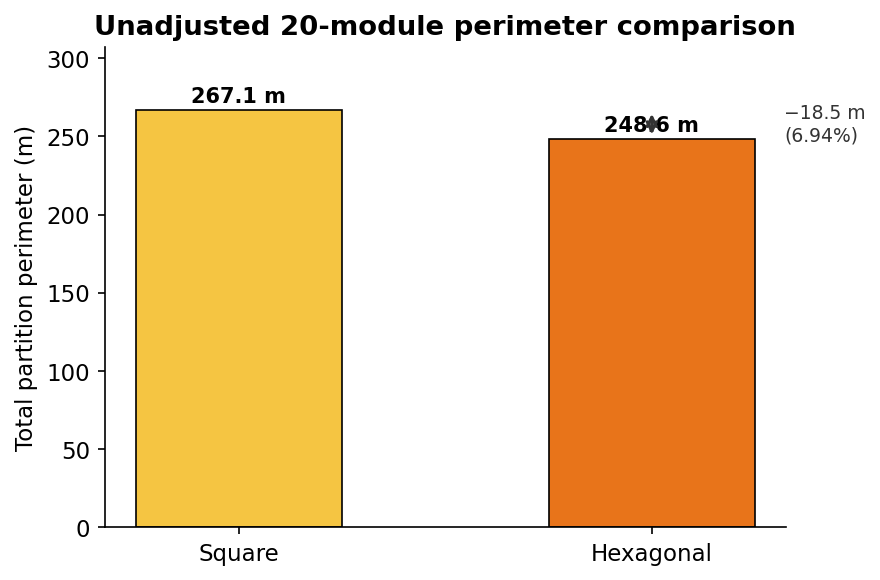

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Square', 'Hexagonal']
values = [P_sq_20, P_hex_20]
colors = [SQ_COLOR, HEX_COLOR]

bars = ax.bar(labels, values, color=colors, edgecolor='k', linewidth=0.8, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2,
            f'{val:.1f} m', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Annotate saving
ax.annotate('', xy=(1, P_hex_20), xytext=(1, P_sq_20),
            arrowprops=dict(arrowstyle='<->', color='#333333', lw=1.5))
ax.text(1.32, (P_sq_20 + P_hex_20)/2,
        f'−{delta_unAdj:.1f} m\n(6.94%)', va='center', fontsize=9, color='#333333')

ax.set_ylabel('Total partition perimeter (m)')
ax.set_title('Unadjusted 20-module perimeter comparison')
ax.set_ylim(0, P_sq_20 * 1.15)

plt.tight_layout()
save_fig('unadjusted_bar')

<a id='s3'></a>
## 3. Sensitivity analysis – perimeter vs module area

ε across range: min=6.9395%, max=6.9395% → constant


Saved → perimeter_comparison.pdf / .png


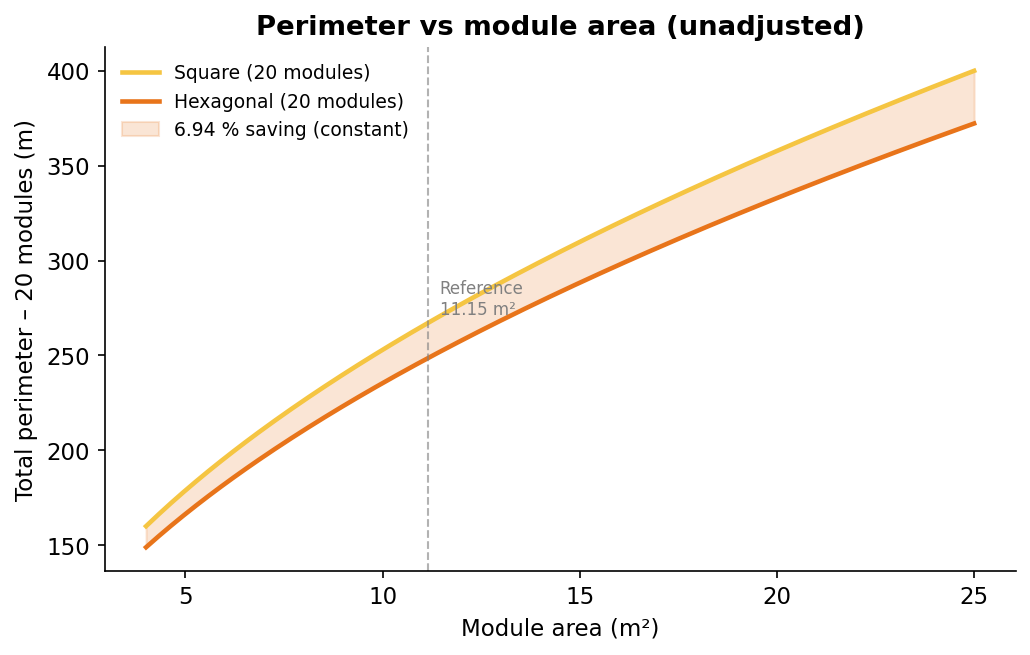

In [4]:
areas = np.linspace(4, 25, 200)

l_sq_arr  = np.sqrt(areas)
P_sq_arr  = N_modules * 4 * l_sq_arr

l_hex_arr = np.sqrt(2 * areas / (3 * np.sqrt(3)))
P_hex_arr = N_modules * 6 * l_hex_arr

# Verify constant ratio
ratios = (P_sq_arr - P_hex_arr) / P_sq_arr
print(f'ε across range: min={ratios.min()*100:.4f}%, max={ratios.max()*100:.4f}% → constant')

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(areas, P_sq_arr,  color=SQ_COLOR,  lw=2.2, label='Square (20 modules)')
ax.plot(areas, P_hex_arr, color=HEX_COLOR, lw=2.2, label='Hexagonal (20 modules)')
ax.fill_between(areas, P_hex_arr, P_sq_arr, alpha=0.18, color=HEX_COLOR, label='6.94 % saving (constant)')

# Mark reference point
ax.axvline(A_module, color='grey', lw=1, ls='--', alpha=0.6)
ax.text(A_module + 0.3, P_sq_arr[np.argmin(np.abs(areas - A_module))] + 4,
        f'Reference\n{A_module} m²', fontsize=8, color='grey')

ax.set_xlabel('Module area (m²)')
ax.set_ylabel('Total perimeter – 20 modules (m)')
ax.set_title('Perimeter vs module area (unadjusted)')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
save_fig('perimeter_comparison')

<a id='s4'></a>
## 4. Adjusted perimeter – wall sharing and passages

Adjusted perimeter analysis
  Square   – walls removed: 39 × 3.339 m = 130.23 m → adj P = 136.9 m
  Hexagon  – walls removed: 46 × 2.072 m = 95.29 m → adj P = 153.3 m
  Δ (hex − sq adj) = +16.4 m = +12.0% (hexagon needs MORE)


Saved → adjusted_comparison.pdf / .png


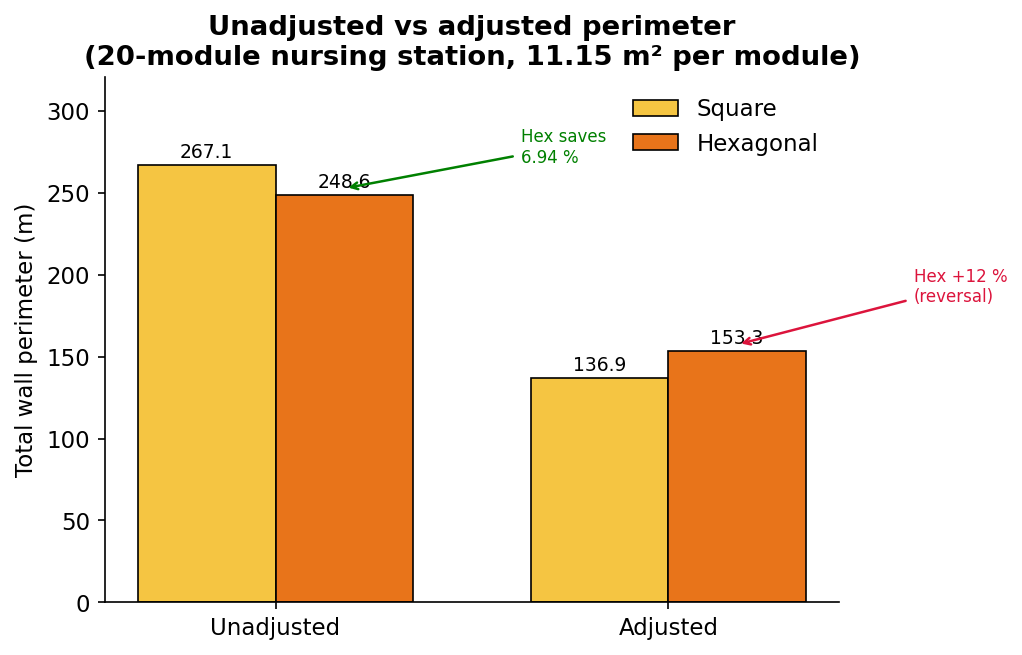

In [5]:
# ── Wall-removal counts from floor plan visual inspection ────────────────────
#   Square : 39 walls (8 patient + 31 nursing station)
#   Hexagon: 46 walls (11 patient + 35 nursing station)
walls_removed_sq  = 39
walls_removed_hex = 46

material_removed_sq  = walls_removed_sq  * l_sq
material_removed_hex = walls_removed_hex * l_hex

P_sq_adj  = P_sq_20  - material_removed_sq
P_hex_adj = P_hex_20 - material_removed_hex

delta_adj = P_hex_adj - P_sq_adj

print('Adjusted perimeter analysis')
print(f'  Square   – walls removed: {walls_removed_sq} × {l_sq:.3f} m = {material_removed_sq:.2f} m → adj P = {P_sq_adj:.1f} m')
print(f'  Hexagon  – walls removed: {walls_removed_hex} × {l_hex:.3f} m = {material_removed_hex:.2f} m → adj P = {P_hex_adj:.1f} m')
print(f'  Δ (hex − sq adj) = +{delta_adj:.1f} m = +{delta_adj/P_sq_adj*100:.1f}% (hexagon needs MORE)')

# ── Figure ──────────────────────────────────────────────────────────────────
categories = ['Unadjusted', 'Adjusted']
sq_vals  = [P_sq_20,  P_sq_adj]
hex_vals = [P_hex_20, P_hex_adj]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))

bars_sq  = ax.bar(x - width/2, sq_vals,  width, color=SQ_COLOR,  edgecolor='k', lw=0.8, label='Square')
bars_hex = ax.bar(x + width/2, hex_vals, width, color=HEX_COLOR, edgecolor='k', lw=0.8, label='Hexagonal')

for bar, val in zip(list(bars_sq) + list(bars_hex), sq_vals + hex_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# Annotate the reversal
ax.annotate('Hex saves\n6.94 %',
            xy=(x[0]+width/2, P_hex_20+4), xytext=(x[0]+width/2+0.45, P_hex_20+20),
            fontsize=8, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.2))
ax.annotate('Hex +12 %\n(reversal)',
            xy=(x[1]+width/2, P_hex_adj+4), xytext=(x[1]+width/2+0.45, P_hex_adj+30),
            fontsize=8, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Total wall perimeter (m)')
ax.set_title('Unadjusted vs adjusted perimeter\n(20-module nursing station, 11.15 m² per module)')
ax.legend(frameon=False)
ax.set_ylim(0, P_sq_20 * 1.20)

plt.tight_layout()
save_fig('adjusted_comparison')

<a id='s5'></a>
## 5. Cost analysis

Cost analysis (MXN):
  Unadjusted – Square: 494,196  Hex: 459,901  → Hex saves 34,295
  Adjusted   – Square: 253,275   Hex: 283,606  → Square saves 30,330


Saved → cost_comparison.pdf / .png


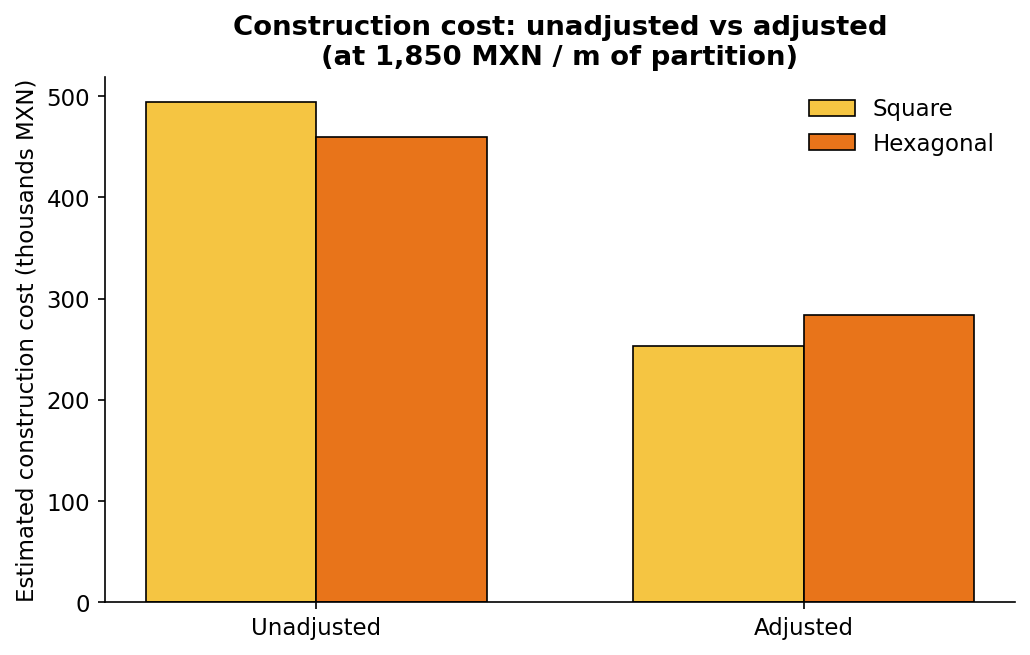

In [6]:
# Costs
cost_sq_unAdj  = P_sq_20  * COST_PER_M
cost_hex_unAdj = P_hex_20 * COST_PER_M
cost_sq_adj    = P_sq_adj  * COST_PER_M
cost_hex_adj   = P_hex_adj * COST_PER_M

print('Cost analysis (MXN):')
print(f'  Unadjusted – Square: {cost_sq_unAdj:,.0f}  Hex: {cost_hex_unAdj:,.0f}  → Hex saves {cost_sq_unAdj - cost_hex_unAdj:,.0f}')
print(f'  Adjusted   – Square: {cost_sq_adj:,.0f}   Hex: {cost_hex_adj:,.0f}  → Square saves {cost_hex_adj - cost_sq_adj:,.0f}')

scenarios = ['Unadjusted', 'Adjusted']
sq_costs  = [cost_sq_unAdj,  cost_sq_adj]
hex_costs = [cost_hex_unAdj, cost_hex_adj]

x = np.arange(2)
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width/2, np.array(sq_costs)/1000,  width, color=SQ_COLOR,  edgecolor='k', lw=0.8, label='Square')
ax.bar(x + width/2, np.array(hex_costs)/1000, width, color=HEX_COLOR, edgecolor='k', lw=0.8, label='Hexagonal')

ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel('Estimated construction cost (thousands MXN)')
ax.set_title('Construction cost: unadjusted vs adjusted\n(at 1,850 MXN / m of partition)')
ax.legend(frameon=False)

plt.tight_layout()
save_fig('cost_comparison')

<a id='s6'></a>
## 6. Circulation crossing points – schematic

Saved → crossing_points.pdf / .png


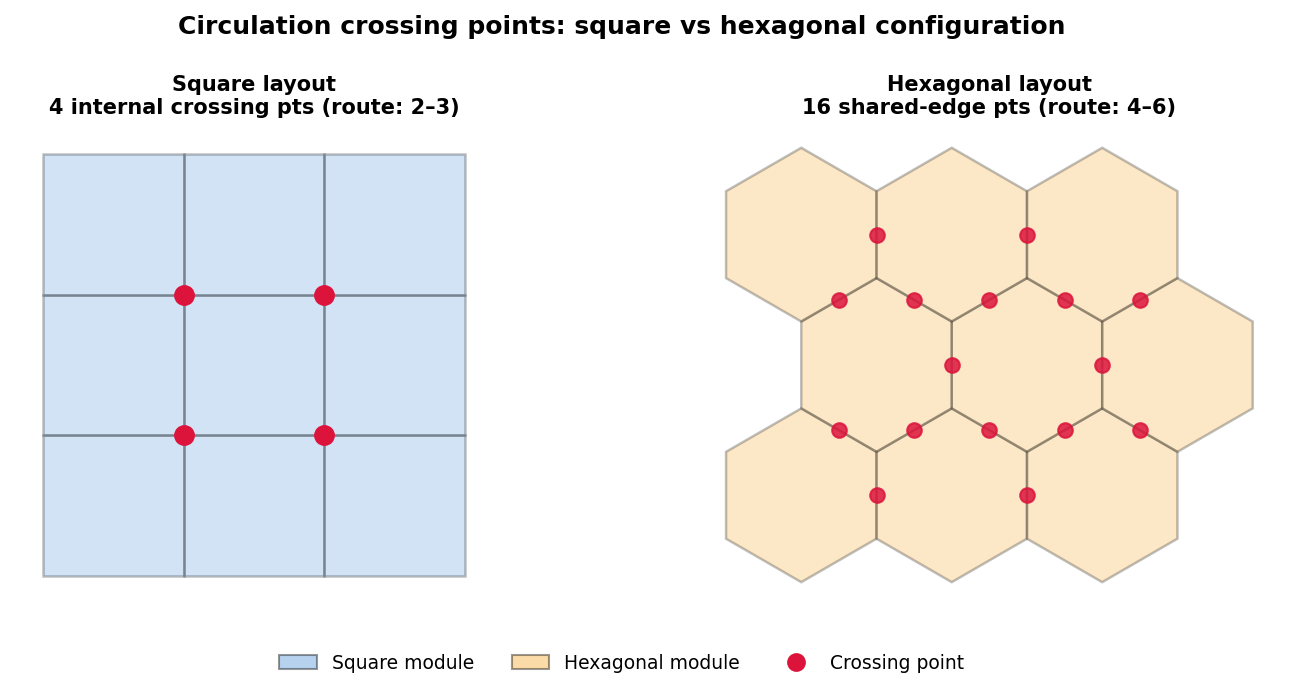

In [7]:
def draw_square_grid(ax, n=3, origin=(0,0), side=1.0, color='#4A90D9', alpha=0.25):
    """Draw an n×n grid of squares with crossing points marked."""
    ox, oy = origin
    for i in range(n):
        for j in range(n):
            rect = plt.Rectangle((ox + i*side, oy + j*side), side, side,
                                  facecolor=color, edgecolor='k', lw=1.2, alpha=alpha)
            ax.add_patch(rect)
    # Internal crossing points (interior vertices)
    crossing_pts = []
    for i in range(1, n):
        for j in range(1, n):
            crossing_pts.append((ox + i*side, oy + j*side))
    for (cx, cy) in crossing_pts:
        ax.plot(cx, cy, 'o', color='crimson', markersize=9, zorder=5)
    return crossing_pts

def hexagon_center(row, col, side=1.0, origin=(0,0)):
    """Offset-coordinate hex grid center."""
    ox, oy = origin
    w = np.sqrt(3) * side
    h = 2 * side
    x = ox + col * w + (row % 2) * (w/2)
    y = oy + row * (h * 0.75)
    return x, y

def hex_vertices(cx, cy, side=1.0):
    angles = np.linspace(30, 390, 7) * np.pi / 180
    return [(cx + side*np.cos(a), cy + side*np.sin(a)) for a in angles]

def draw_hex_grid(ax, rows=3, cols=3, side=0.65, origin=(4.5, 0), color='#F5A623', alpha=0.25):
    """Draw a hexagonal grid with crossing points at shared vertices."""
    centers = []
    for r in range(rows):
        for c in range(cols):
            cx, cy = hexagon_center(r, c, side, origin)
            verts = hex_vertices(cx, cy, side)
            poly = plt.Polygon(verts[:-1], closed=True,
                                facecolor=color, edgecolor='k', lw=1.2, alpha=alpha)
            ax.add_patch(poly)
            centers.append((cx, cy))
    # Crossing points: approximate as midpoints between adjacent hex centers
    crossing_pts = []
    for i in range(len(centers)):
        for j in range(i+1, len(centers)):
            d = np.hypot(centers[i][0]-centers[j][0], centers[i][1]-centers[j][1])
            if d < side * 2.1:  # adjacent
                mx = (centers[i][0]+centers[j][0])/2
                my = (centers[i][1]+centers[j][1])/2
                crossing_pts.append((mx, my))
    # Deduplicate approximately
    dedup = []
    for pt in crossing_pts:
        if not any(np.hypot(pt[0]-q[0], pt[1]-q[1]) < 0.05 for q in dedup):
            dedup.append(pt)
    for (cx, cy) in dedup:
        ax.plot(cx, cy, 'o', color='crimson', markersize=7, zorder=5, alpha=0.85)
    return dedup

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Left: 3×3 square grid
sq_cp = draw_square_grid(axes[0], n=3, side=1.0)
axes[0].set_xlim(-0.2, 3.2);  axes[0].set_ylim(-0.2, 3.2)
axes[0].set_aspect('equal');   axes[0].axis('off')
axes[0].set_title(f'Square layout\n{len(sq_cp)} internal crossing pts (route: 2–3)', fontsize=10)

# Right: hex grid
hex_cp = draw_hex_grid(axes[1], rows=3, cols=3, side=0.65, origin=(0, 0))
axes[1].set_aspect('equal');  axes[1].axis('off')
axes[1].set_title(f'Hexagonal layout\n{len(hex_cp)} shared-edge pts (route: 4–6)', fontsize=10)

# Common legend
patch_sq  = mpatches.Patch(facecolor='#4A90D9', edgecolor='k', alpha=0.4, label='Square module')
patch_hex = mpatches.Patch(facecolor='#F5A623', edgecolor='k', alpha=0.4, label='Hexagonal module')
dot       = plt.Line2D([0],[0], marker='o', color='crimson', markersize=8, lw=0, label='Crossing point')
fig.legend(handles=[patch_sq, patch_hex, dot], loc='lower center',
           ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Circulation crossing points: square vs hexagonal configuration', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 1])
save_fig('crossing_points')

<a id='s7'></a>
## 7. Proposed floor plan diagrams (generated)

Saved → floorplan_square.pdf / .png


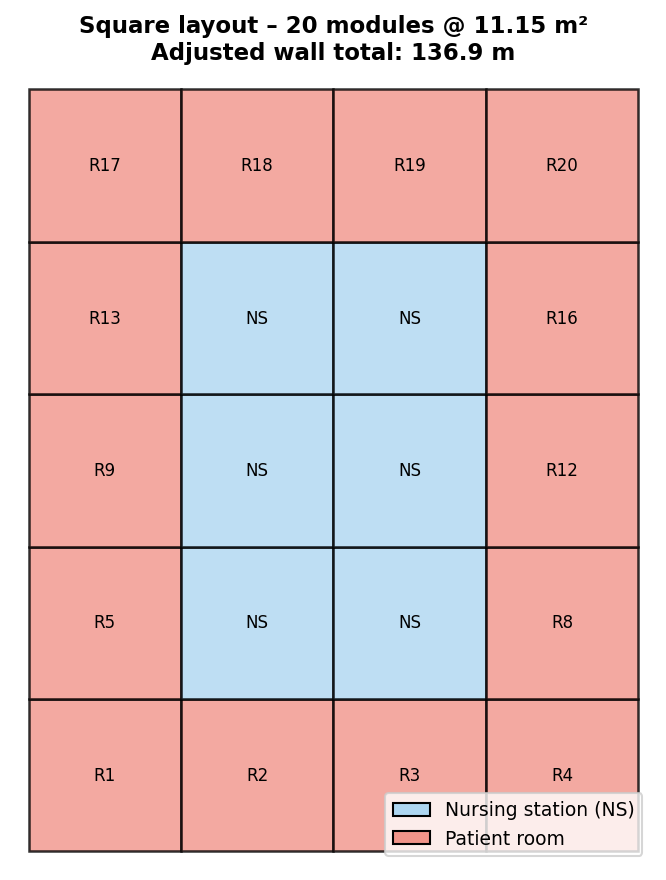

In [8]:
# ── Square floor plan ────────────────────────────────────────────────────────
# Layout: 4 columns × 5 rows = 20 modules
# Central column (col 1,2) = nursing station (blue), others = patient rooms (red)

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_aspect('equal')
ax.axis('off')

COLS, ROWS = 4, 5
s = l_sq  # real side

nursing_cols = {1, 2}
nursing_rows = {1, 2, 3}

module_id = 0
for row in range(ROWS):
    for col in range(COLS):
        is_nursing = (col in nursing_cols) and (row in nursing_rows)
        color = '#AED6F1' if is_nursing else '#F1948A'
        rect = plt.Rectangle((col*s, row*s), s, s,
                              facecolor=color, edgecolor='k', lw=1.2, alpha=0.8)
        ax.add_patch(rect)
        label = 'NS' if is_nursing else f'R{module_id+1}'
        ax.text(col*s + s/2, row*s + s/2, label, ha='center', va='center',
                fontsize=8, color='k')
        module_id += 1

ax.set_xlim(-0.3, COLS*s+0.3)
ax.set_ylim(-0.3, ROWS*s+0.3)
ax.set_title(f'Square layout – 20 modules @ {A_module} m²\nAdjusted wall total: {P_sq_adj:.1f} m',
             fontsize=11, pad=8)

# Legend
p1 = mpatches.Patch(facecolor='#AED6F1', edgecolor='k', label='Nursing station (NS)')
p2 = mpatches.Patch(facecolor='#F1948A', edgecolor='k', label='Patient room')
ax.legend(handles=[p1, p2], loc='lower right', frameon=True, fontsize=9)

plt.tight_layout()
save_fig('floorplan_square')

Saved → floorplan_hexagonal.pdf / .png


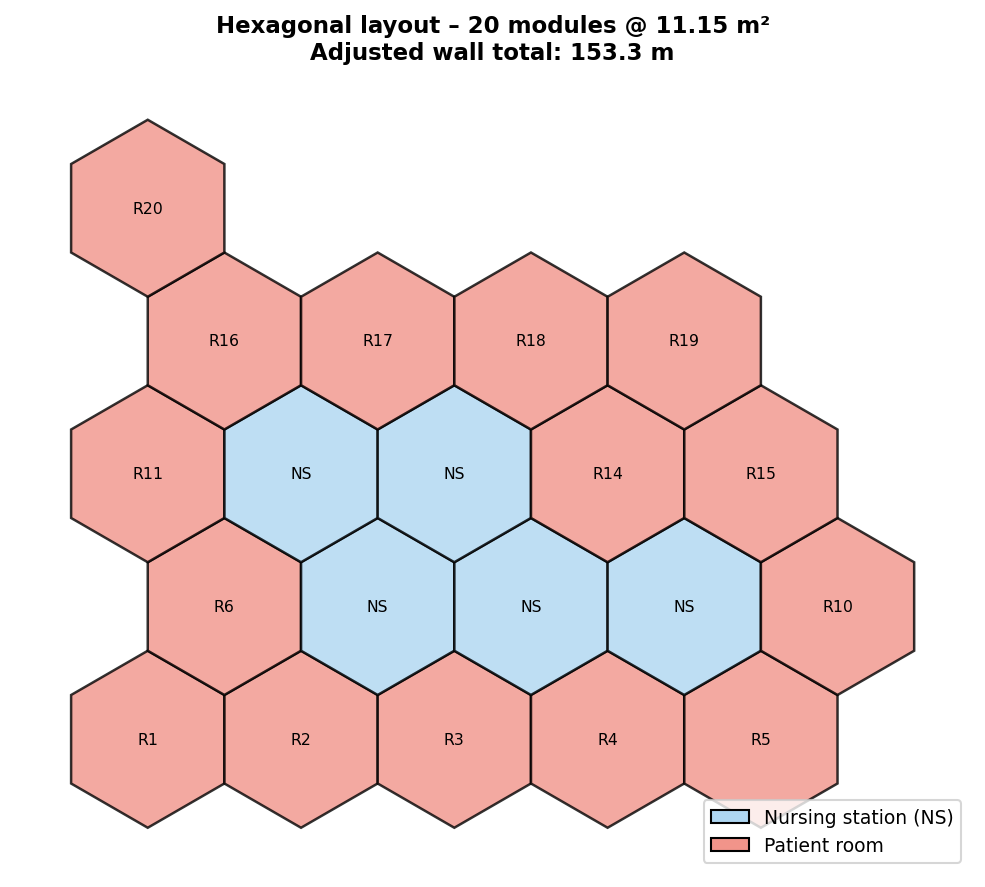

In [9]:
# ── Hexagonal floor plan ─────────────────────────────────────────────────────
# 20 hexagonal modules in offset-row layout

def draw_hex(ax, cx, cy, side, facecolor, edgecolor='k', lw=1.2, alpha=0.8, label=''):
    angles_deg = np.arange(0, 360, 60) + 30
    verts = [(cx + side*np.cos(np.radians(a)), cy + side*np.sin(np.radians(a)))
             for a in angles_deg]
    poly = plt.Polygon(verts, closed=True,
                       facecolor=facecolor, edgecolor=edgecolor, lw=lw, alpha=alpha)
    ax.add_patch(poly)
    if label:
        ax.text(cx, cy, label, ha='center', va='center', fontsize=7.5)

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_aspect('equal')
ax.axis('off')

h_side = l_hex   # real hex side
w_hex  = np.sqrt(3) * h_side
h_vert = 2 * h_side

# Arrange 20 hexagons: 4 rows × 5 or alternating 5/4/5/4/2
layout = [
    [(0,0),(1,0),(2,0),(3,0),(4,0)],      # row 0: 5
    [(0,1),(1,1),(2,1),(3,1),(4,1)],      # row 1: 5
    [(0,2),(1,2),(2,2),(3,2),(4,2)],      # row 2: 5
    [(0,3),(1,3),(2,3),(3,3)],            # row 3: 4
    [(0,4),],                             # row 4: 1
]
# Flatten first 20
positions = [pos for row in layout for pos in row][:20]

nursing_set = {(1,1),(2,1),(1,2),(2,2),(3,1)}

module_id = 0
for (col, row) in positions:
    cx = col * w_hex + (row % 2) * (w_hex/2)
    cy = row * h_vert * 0.75
    is_nursing = (col, row) in nursing_set
    color = '#AED6F1' if is_nursing else '#F1948A'
    label = 'NS' if is_nursing else f'R{module_id+1}'
    draw_hex(ax, cx, cy, h_side, color, label=label)
    module_id += 1

all_cx = [col * w_hex + (row % 2) * (w_hex/2) for (col, row) in positions]
all_cy = [row * h_vert * 0.75 for (col, row) in positions]
margin = h_side * 1.5
ax.set_xlim(min(all_cx) - margin, max(all_cx) + margin)
ax.set_ylim(min(all_cy) - margin, max(all_cy) + margin)
ax.set_title(f'Hexagonal layout – 20 modules @ {A_module} m²\nAdjusted wall total: {P_hex_adj:.1f} m',
             fontsize=11, pad=8)

p1 = mpatches.Patch(facecolor='#AED6F1', edgecolor='k', label='Nursing station (NS)')
p2 = mpatches.Patch(facecolor='#F1948A', edgecolor='k', label='Patient room')
ax.legend(handles=[p1, p2], loc='lower right', frameon=True, fontsize=9)

plt.tight_layout()
save_fig('floorplan_hexagonal')

<a id='s8'></a>
## 8. Expert perception survey (MOCKUP)

Mean ratings:
  Q1: Circulation                 Square=3.40  Hex=4.20
  Q2: Visual                      Square=4.00  Hex=4.00
  Q3: Implementation              Square=4.20  Hex=3.20


Saved → survey_bars.pdf / .png


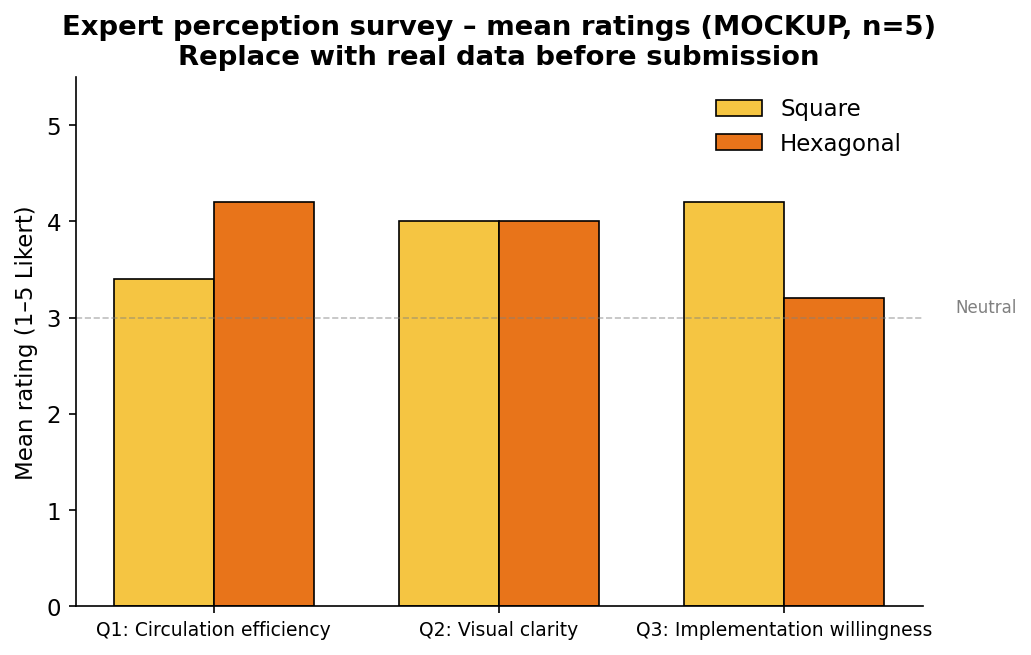

In [10]:
MOCKUP = True  # Set False and replace data below with real responses

if MOCKUP:
    participants = ['P1\nNurse 5yr', 'P2\nNurse 12yr', 'P3\nNurse 3yr',
                    'P4\nArchitect 8yr', 'P5\nManager 10yr']
    questions = ['Q1: Circulation\nefficiency', 'Q2: Visual\nclarity', 'Q3: Implementation\nwillingness']

    # Ratings [participants × questions] for each layout
    sq_ratings = np.array([
        [3, 4, 4],   # P1
        [4, 4, 4],   # P2
        [3, 3, 4],   # P3
        [4, 5, 4],   # P4
        [3, 4, 5],   # P5
    ])
    hex_ratings = np.array([
        [4, 4, 3],   # P1
        [5, 4, 3],   # P2
        [4, 3, 3],   # P3
        [5, 5, 4],   # P4
        [3, 4, 3],   # P5
    ])
else:
    # === REPLACE WITH REAL DATA ===
    # sq_ratings  = np.array([...])  # shape (n_participants, 3)
    # hex_ratings = np.array([...])  # shape (n_participants, 3)
    raise ValueError('Set MOCKUP=False and provide real ratings.')

sq_means  = sq_ratings.mean(axis=0)
hex_means = hex_ratings.mean(axis=0)

print('Mean ratings:')
for q, sm, hm in zip(questions, sq_means, hex_means):
    print(f'  {q.split(chr(10))[0]:30s}  Square={sm:.2f}  Hex={hm:.2f}')

# ── Bar chart ────────────────────────────────────────────────────────────────
x = np.arange(len(questions))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width/2, sq_means,  width, color=SQ_COLOR,  edgecolor='k', lw=0.8, label='Square')
ax.bar(x + width/2, hex_means, width, color=HEX_COLOR, edgecolor='k', lw=0.8, label='Hexagonal')

ax.set_xticks(x)
ax.set_xticklabels([q.replace('\n', ' ') for q in questions], fontsize=9)
ax.set_ylim(0, 5.5)
ax.set_ylabel('Mean rating (1–5 Likert)')
ax.set_title('Expert perception survey – mean ratings (MOCKUP, n=5)\nReplace with real data before submission')
ax.axhline(3, color='grey', ls='--', lw=0.8, alpha=0.5)
ax.text(x[-1]+0.6, 3.05, 'Neutral', fontsize=8, color='grey')
ax.legend(frameon=False)

plt.tight_layout()
save_fig('survey_bars')

Saved → survey_radar.pdf / .png


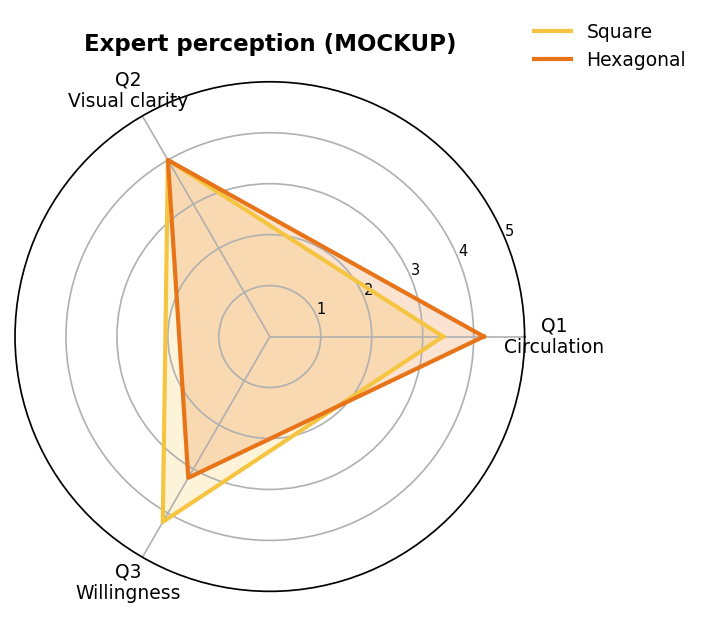

In [11]:
# ── Radar chart ──────────────────────────────────────────────────────────────
labels_radar = ['Q1\nCirculation', 'Q2\nVisual clarity', 'Q3\nWillingness']
num_vars = len(labels_radar)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

sq_vals_r  = sq_means.tolist()  + sq_means[:1].tolist()
hex_vals_r = hex_means.tolist() + hex_means[:1].tolist()

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

ax.plot(angles, sq_vals_r,  color=SQ_COLOR,  lw=2, label='Square')
ax.fill(angles, sq_vals_r,  color=SQ_COLOR,  alpha=0.20)
ax.plot(angles, hex_vals_r, color=HEX_COLOR, lw=2, label='Hexagonal')
ax.fill(angles, hex_vals_r, color=HEX_COLOR, alpha=0.20)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=9)
ax.set_ylim(0, 5)
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels(['1','2','3','4','5'], fontsize=7)
ax.set_title('Expert perception (MOCKUP)', fontsize=11, pad=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), frameon=False, fontsize=9)

plt.tight_layout()
save_fig('survey_radar')

<a id='s9'></a>
## 9. Summary table

In [12]:
summary = pd.DataFrame({
    'Metric': [
        'Side length (m)',
        'Perimeter per module (m)',
        'Area per module (m²)',
        'Total unadjusted perimeter (m)',
        'Walls removed (n)',
        'Material removed (m)',
        'Adjusted perimeter (m)',
        'Unadjusted cost (MXN)',
        'Adjusted cost (MXN)',
        'Crossing points / route',
    ],
    'Square': [
        f'{l_sq:.3f}',
        f'{P_sq:.3f}',
        f'{A_module:.2f}',
        f'{P_sq_20:.2f}',
        f'{walls_removed_sq}',
        f'{material_removed_sq:.2f}',
        f'{P_sq_adj:.1f}',
        f'{cost_sq_unAdj:,.0f}',
        f'{cost_sq_adj:,.0f}',
        '2–3',
    ],
    'Hexagonal': [
        f'{l_hex:.3f}',
        f'{P_hex:.3f}',
        f'{A_module:.2f}',
        f'{P_hex_20:.2f}',
        f'{walls_removed_hex}',
        f'{material_removed_hex:.2f}',
        f'{P_hex_adj:.1f}',
        f'{cost_hex_unAdj:,.0f}',
        f'{cost_hex_adj:,.0f}',
        '4–6',
    ],
    'Notes': [
        '37.97% shorter side',
        '6.94% less / module',
        'Equal by design',
        '6.94% saving',
        'From floor plan inspection',
        'See Section 4 methods',
        '**HEX +12.0% after adj.**',
        'Hex saves 34,299 MXN',
        'Square saves 30,340 MXN',
        'Hex doubles options',
    ]
})

print(summary.to_string(index=False))

                        Metric  Square Hexagonal                      Notes
               Side length (m)   3.339     2.072        37.97% shorter side
      Perimeter per module (m)  13.357    12.430        6.94% less / module
          Area per module (m²)   11.15     11.15            Equal by design
Total unadjusted perimeter (m)  267.13    248.60               6.94% saving
             Walls removed (n)      39        46 From floor plan inspection
          Material removed (m)  130.23     95.29      See Section 4 methods
        Adjusted perimeter (m)   136.9     153.3  **HEX +12.0% after adj.**
         Unadjusted cost (MXN) 494,196   459,901       Hex saves 34,299 MXN
           Adjusted cost (MXN) 253,275   283,606    Square saves 30,340 MXN
       Crossing points / route     2–3       4–6        Hex doubles options
